# Ocean Carbon Sampling
## A map-first visual story of fixed-budget observing strategies

<div style="padding:16px 18px;border-left:5px solid #0F766E;background:#F0FDFA;">
<b>Question</b><br>Under a fixed annual observation budget, does changing <i>where</i> we sample redistribute global monthly reconstruction risk?
</div>

**Demo status:** scientific content is source-grounded; layout remains open for portfolio refinement.

### Visual inheritance and redesign

This demo inherits the strongest visual language of the earlier course project: Pacific-centred Robinson maps, dark land, oceanographic colour maps, shared horizontal colour bars, and spatial comparisons before summary statistics. It replaces oversized canvases, repeated legends, and significance-first panels with a compact sequence: **observing geometry → hidden-set error geography → paired-seed evidence**.

In [1]:
from pathlib import Path

import pandas as pd

from ocean_carbon_sampling.demo_visuals import (
    plot_budget_sweep,
    plot_error_atlas,
    plot_sampling_atlas,
    plot_spatial_holdout_gate,
)

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
RESULTS = ROOT / 'results' / 'public'
fields = pd.read_parquet(RESULTS / 'osse_visual_demo_fields.parquet')
sampling = pd.read_parquet(RESULTS / 'osse_visual_demo_sampling.parquet')
metadata = pd.read_csv(RESULTS / 'osse_visual_demo_metadata.csv')
effects = pd.read_csv(RESULTS / 'osse_cross_year_paired_summary.csv')
regrid = pd.read_csv(RESULTS / 'osse_regrid_audit_paired_summary.csv')
spatial_blocks = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_blocks.csv')
spatial_summary = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_paired_summary.csv')
month_balance = pd.read_csv(RESULTS / 'osse_month_balance_strategy_summary.csv')
claim_summary = pd.read_csv(RESULTS / 'osse_claim_distribution_summary.csv')
print('Curated visual-demo data loaded.')

Curated visual-demo data loaded.


In [2]:
metadata.rename(columns={
    'complete_month_cells': 'complete month-grid cells',
    'evaluation_month_cells': 'hidden evaluation rows',
    'map_grid_cells': 'mapped spatial cells',
})

,year,seed,error_map_seeds,n_error_map_seeds,budget,complete month-grid cells,candidate_month_cells,hidden evaluation rows,mapped spatial cells,sampling_longitude_degrees,sampling_latitude_degrees,map_role
0,2005,0,0;1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;19,20,5000,487488,390000,97488,40624,10.0,5.0,error fields are paired-seed means; sampling g...


## 0 · What is being predicted—and why monthly?

This project evaluates **reconstruction under a fixed annual sample count**, not future-time forecasting. The truth field is monthly surface-ocean `spco2` from the CMIP6 IPSL-CM6A-LR historical Earth-system-model simulation (`r1i1p1f1`)—not a SOCAT-derived reconstruction. SST and salinity from the same simulation are predictors; SOCAT only defines the historical observing-pattern baseline.

Each record is a month–location observation, but all 12 months are fitted jointly in one model. Cyclic month features preserve the seasonal cycle and keep December adjacent to January.

The random hidden set is stratified by month so every season has the same evaluation fraction; otherwise seasonal test composition could be mistaken for a sampling-strategy effect. In the stricter spatial holdout, all 12 months from one location stay in the same fold, preventing the model from training on another month at the evaluation location. A chronological split would instead test forecasting under temporal distribution shift—a valid but different question.

In [3]:
month_balance_appendix = month_balance.query('budget == 5000').assign(
    strategy=lambda frame: frame['strategy'].replace({
        'random': 'Random',
        'spatial_coverage': 'Seasonally balanced spatial coverage',
        'historical_density': 'Historical spatiotemporal pattern',
    }),
    mean_abs_equal_deviation_pp=lambda frame: frame['mean_abs_equal_deviation_pp'].round(3),
    mean_max_abs_equal_deviation_pp=lambda frame: frame['mean_max_abs_equal_deviation_pp'].round(3),
)[['strategy', 'n_year_fold_seed_selections', 'minimum_months_covered',
   'mean_abs_equal_deviation_pp', 'mean_max_abs_equal_deviation_pp']]

A selection-only audit confirms that all 1,800 selections cover all 12 months and that random and coverage have closely matched month shares. The detailed audit is moved to the appendix. Historical density remains a realistic **spatiotemporal** baseline, not a pure spatial control.

## 1 · Same budget, different observing geometry

Each strategy selects exactly 5,000 month-grid observations from the same candidate pool. Random and seasonally balanced spatial coverage have closely matched monthly allocation, so this map isolates their main difference: where observations are placed. Colour encodes the number selected within each 5° × 10° spatial block; no observations are discarded for plotting.

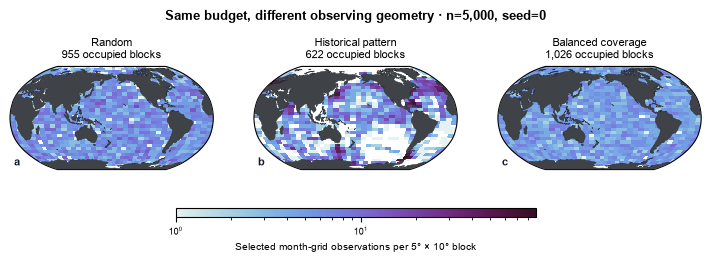

In [4]:
sampling_figure = plot_sampling_atlas(sampling, budget=5000, seed=0)

<div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:10px;margin:10px 0 22px 0;">
<div style="padding:10px;background:#F9FAFB;border-radius:6px;"><b>Random</b><br>Broad but uneven by chance.</div>
<div style="padding:10px;background:#FFF7ED;border-radius:6px;"><b>Historical pattern</b><br>Reproduces seasonal and spatial observation density.</div>
<div style="padding:10px;background:#F0FDFA;border-radius:6px;"><b>Balanced spatial coverage</b><br>Cycles across month × under-filled spatial blocks.</div>
</div>

## 2 · Where does coverage change error?

The maps below use every row of the locked 2005 hidden evaluation set and average absolute error over all 20 paired seeds. The hero panel shows the change in mean absolute error: blue cells favour coverage; red cells favour random. Stippling marks cells where at least 16/20 seed-level spatial ΔMAE values share the same sign. Values beyond the 98th percentile are colour-clipped only to protect contrast; they remain in all calculations.

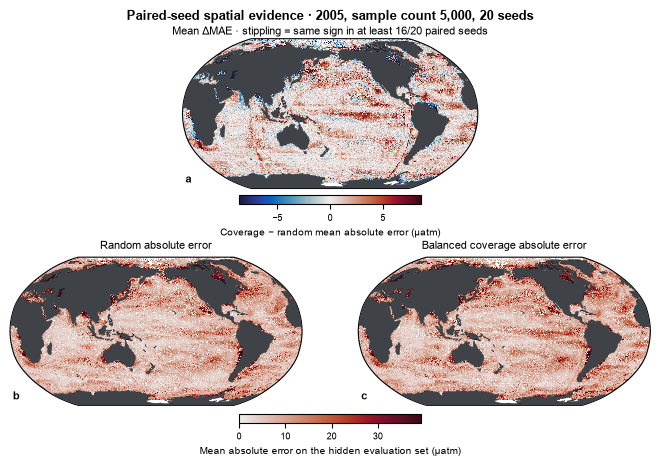

In [5]:
error_figure = plot_error_atlas(fields)

**Reading boundary.** This map uses 2005 and sample count 5,000 to localise the 20-seed paired effect. It is now quantitative spatial evidence, but the grid cells are not independent replicates; inference remains at the paired-seed and year–fold levels.

## 3 · Does the result depend on sample count?

The figure uses every locked sample count (500, 1,000, 2,500 and 5,000), all 20 paired sampling seeds and each of three prespecified years. Points are paired-seed mean differences and intervals are 10,000-resample seed-bootstrap 95% intervals. The three metrics and three years are correlated views of the same experiment, not independent tests.

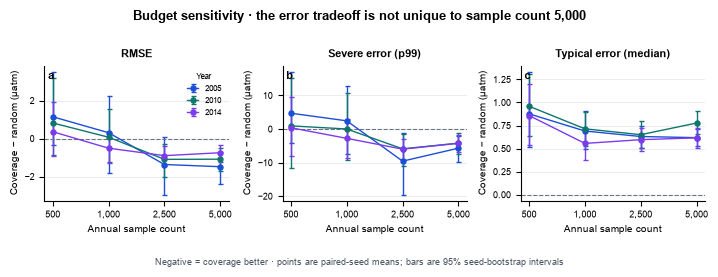

In [6]:
key_effects = effects.query(
    "evaluation_domain == 'all' and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
).copy()
budget_sweep_figure = plot_budget_sweep(key_effects)

In [7]:
key_effects.query('budget == 5000').assign(
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    seed_bootstrap_low=lambda frame: frame['seed_bootstrap_low'].round(3),
    seed_bootstrap_high=lambda frame: frame['seed_bootstrap_high'].round(3),
)[[
    'year', 'metric', 'n_seeds', 'mean_difference',
    'seed_bootstrap_low', 'seed_bootstrap_high',
]].sort_values(['metric', 'year'])

,year,metric,n_seeds,mean_difference,seed_bootstrap_low,seed_bootstrap_high
36,2005,median_absolute_error,20,0.618,0.525,0.709
116,2010,median_absolute_error,20,0.777,0.655,0.904
196,2014,median_absolute_error,20,0.616,0.509,0.726
38,2005,p99_absolute_error,20,-5.701,-9.844,-1.952
118,2010,p99_absolute_error,20,-4.207,-7.562,-1.113
198,2014,p99_absolute_error,20,-4.253,-6.767,-1.877
39,2005,rmse,20,-1.484,-2.376,-0.701
119,2010,rmse,20,-1.088,-1.705,-0.507
199,2014,rmse,20,-0.749,-1.213,-0.315


**Budget boundary.** Coverage is worse than random in all three years at sample count 500 for RMSE and p99. The hidden-cell RMSE and p99 advantage appears consistently only at 2,500 and 5,000; median error remains higher at every tested sample count. The claim is therefore budget-dependent, not a universal property of coverage.

### Supporting audit · Spatial weighting

Replacing equal weighting within one-degree bins with native-cell-area weighting preserves all 12 prespecified direction checks: coverage still lowers RMSE and p99 error, raises median error, and historical-density allocation remains worse than random on RMSE.

In [8]:
audit_filter = (
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
)
equal_bin = key_effects.assign(method='equal-bin baseline')
area_weighted = regrid.query(audit_filter).assign(method='native-cell-area audit')
robustness = pd.concat([equal_bin, area_weighted], ignore_index=True)
robustness.pivot_table(
    index=['year', 'metric'], columns='method', values='mean_difference'
).round(3);

## 4 · Stricter validation: whole regions unseen

### What is a Global spatial-block holdout OSSE?

An **OSSE** (Observing System Simulation Experiment) treats a complete climate-model field as known truth, simulates where observations would be collected, reconstructs the unsampled ocean, and scores that reconstruction against the truth. A **spatial-block holdout** makes the test harder: instead of hiding scattered cells, it withholds whole geographic blocks. The model therefore cannot learn from another month at the same location or from a randomly hidden neighbour inside the held-out block.

Here, all 12 months of each 20° × 10° block stay together. Five checkerboard folds exhaust the occupied ocean blocks: one fold is evaluated while the other four provide candidates, repeated until every block has been held out once. The confirmatory comparison repeats this design in the prespecified years 2005, 2010 and 2014, using the same model, equal budgets, 20 paired sampling seeds per year–fold, and seed-bootstrap intervals. There is no extra buffer around held-out blocks, so this is a coarse unseen-region gate rather than a long-range extrapolation test.

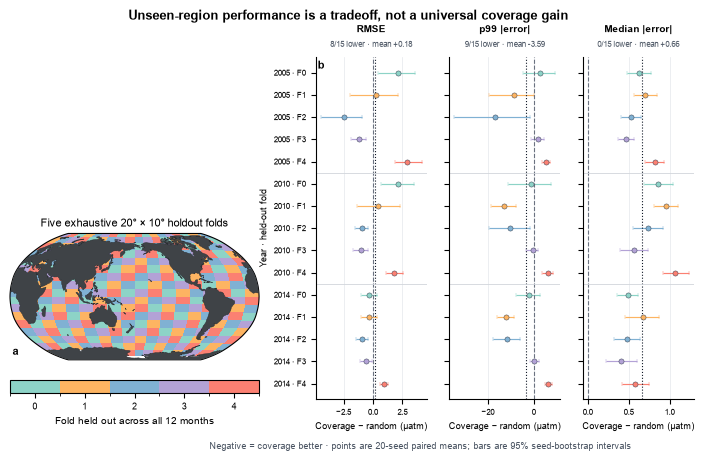

In [9]:
spatial_gate_figure = plot_spatial_holdout_gate(spatial_blocks, spatial_summary)

**What changed under the stricter gate?** At sample count 5,000, coverage has lower RMSE in 8/15 year–fold units and higher RMSE in 7/15; the descriptive mean is **+0.179 µatm**. MAE and median absolute error are higher in all 15 units, and p95 is higher in 14/15. The mean p99 difference is **−3.590 µatm**, but only 9/15 units favour coverage; its directional consistency is too weak to call a stable tail benefit. Negative differences favour coverage.

This defines the random hidden-cell result's boundary. Under whole-block validation, coverage loses through the median, MAE and p95, while a subset of large p99 improvements pulls the tail mean negative. The 15 year–fold units are a descriptive consistency check, not independent replicates; the three years share persistent spatial structure because they come from the same model run.

## 5 · Absolute scale and year–fold distribution

Differences alone are not enough to judge practical size. The first table reports random and coverage absolute values at sample count 5,000, plus percentage change for non-signed metrics. The second reports the full distribution across validation units rather than only the mean.

In [10]:
absolute_scale = claim_summary.query(
    "budget == 5000 and comparison == 'spatial_coverage_minus_random'"
).assign(
    validation=lambda frame: frame['validation_scheme'].replace({
        'month_stratified_hidden_cells': 'Hidden cells',
        'whole_spatial_blocks': 'Whole blocks',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    coverage=lambda frame: frame['mean_comparator_value'].round(3),
    difference=lambda frame: frame['mean_difference'].round(3),
    relative_change_percent=lambda frame: frame['mean_relative_error_change_percent'].round(2),
)[['validation', 'metric', 'random', 'coverage', 'difference',
   'relative_change_percent']]
absolute_scale.sort_values(['validation', 'metric'])

,validation,metric,random,coverage,difference,relative_change_percent
42,Hidden cells,bias,0.065,0.071,0.006,NaN
43,Hidden cells,mae,10.936,11.436,0.500,4.56
44,Hidden cells,median_absolute_error,7.083,7.754,0.670,9.47
45,Hidden cells,p95_absolute_error,30.696,31.785,1.090,3.55
46,Hidden cells,p99_absolute_error,66.406,61.686,-4.720,-7.10
47,Hidden cells,rmse,25.936,24.829,-1.107,-4.23
66,Whole blocks,bias,0.104,0.256,0.152,NaN
67,Whole blocks,mae,12.828,13.460,0.632,4.94
68,Whole blocks,median_absolute_error,8.295,8.958,0.663,8.03
69,Whole blocks,p95_absolute_error,36.588,37.846,1.257,3.44


In [11]:
claim_summary.query(
    "validation_scheme == 'whole_spatial_blocks' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random'"
).assign(
    median=lambda frame: frame['median_difference'].round(3),
    q25=lambda frame: frame['q25_difference'].round(3),
    q75=lambda frame: frame['q75_difference'].round(3),
    minimum=lambda frame: frame['minimum_difference'].round(3),
    maximum=lambda frame: frame['maximum_difference'].round(3),
)[['metric', 'n_units', 'median', 'q25', 'q75', 'minimum', 'maximum',
   'units_below_zero', 'units_above_zero']].sort_values('metric')

,metric,n_units,median,q25,q75,minimum,maximum,units_below_zero,units_above_zero
66,bias,15,0.320,-0.429,0.557,-0.657,1.017,6,9
67,mae,15,0.550,0.383,0.815,0.160,1.379,0,15
68,median_absolute_error,15,0.626,0.509,0.775,0.409,1.069,0,15
69,p95_absolute_error,15,1.273,0.601,1.635,-0.023,3.055,1,14
70,p99_absolute_error,15,-1.002,-11.106,2.207,-16.788,6.294,9,6
71,rmse,15,-0.321,-0.940,1.368,-2.496,2.922,8,7


The whole-block p99 mean is −3.590 µatm, but its median is only −1.002 µatm, its IQR spans −11.106 to +2.207 µatm, and its range is −16.788 to +6.294 µatm. A subset of large improvements therefore influences the mean. Signed mean error is also retained: random averages +0.104 µatm and coverage +0.256 µatm under whole-block validation.

A pointwise µatm error is not converted directly to PgC yr⁻¹: air–sea flux also requires gas-transfer velocity, solubility, atmospheric pCO₂ and cell area. Integrated flux is a separate, not-yet-supported decision metric.

---
## Result

<div style="padding:18px;background:#111827;color:#F9FAFB;border-radius:8px;font-size:16px;line-height:1.45;">
This project turns an observing-system design question into a reproducible sequence of increasingly strict OSSE gates. Under whole-block validation, balanced coverage consistently raises typical and p95 error; its RMSE effect is region-dependent, and its negative mean p99 shift is not directionally stable.
</div>

**Strong result:** reproducing the complete historical spatiotemporal observing pattern is much worse than random for pointwise reconstruction under this objective, although its spatial and monthly contributions are not separated.  
**Bounded result:** coverage changes the error distribution, but no stable unseen-region tail advantage is established.  
**Not yet supported:** universal superiority, buffered extrapolation, cost-aware design, integrated air–sea carbon-flux accuracy, cross-model robustness, or direct real-ocean performance.

---
## Appendix · Monthly allocation audit

This table is a design audit, not part of the main inferential sequence. It reconstructs all 1,800 acquisition choices without additional model fitting. Deviation values are percentage points from an equal one-twelfth monthly share.

In [12]:
month_balance_appendix

,strategy,n_year_fold_seed_selections,minimum_months_covered,mean_abs_equal_deviation_pp,mean_max_abs_equal_deviation_pp
3,Historical spatiotemporal pattern,300,12,0.875,2.506
4,Random,300,12,0.292,0.754
5,Seasonally balanced spatial coverage,300,12,0.222,0.532
